In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

## Loading Data

In [4]:
df1 = pd.read_csv("/Users/harrychang/Desktop/GE5219/data/HistoricalRainfallacrossSingapore/Historical Rainfall across Singapore (2024).csv")
df2 = pd.read_csv("/Users/harrychang/Desktop/GE5219/data/HistoricalAirTemperatureacrossSingapore2024.csv")
df3 = pd.read_csv("/Users/harrychang/Desktop/GE5219/data/HistoricalRelativeHumidityacrossSingapore2024.csv")
df4 = pd.read_csv("/Users/harrychang/Desktop/GE5219/data/HistoricalWindDirectionacrossSingapore2024.csv")
df5 = pd.read_csv("/Users/harrychang/Desktop/GE5219/data/HistoricalWindSpeedacrossSingapore2024.csv")

In [5]:
print(df1.columns,df2.columns,df3.columns,df4.columns,df5.columns)

Index(['date', 'timestamp', 'update_timestamp', 'station_id', 'station_name',
       'station_device_id', 'location_longitude', 'location_latitude',
       'reading_update_timestamp', 'reading_value', 'reading_type',
       'reading_unit'],
      dtype='object') Index(['date', 'timestamp', 'update_timestamp', 'station_id', 'station_name',
       'station_device_id', 'location_longitude', 'location_latitude',
       'reading_update_timestamp', 'reading_value', 'reading_type',
       'reading_unit'],
      dtype='object') Index(['date', 'timestamp', 'update_timestamp', 'station_id', 'station_name',
       'station_device_id', 'location_longitude', 'location_latitude',
       'reading_update_timestamp', 'reading_value', 'reading_unit'],
      dtype='object') Index(['date', 'timestamp', 'update_timestamp', 'station_id', 'station_name',
       'station_device_id', 'location_longitude', 'location_latitude',
       'reading_update_timestamp', 'reading_value', 'reading_type',
       'reading_u

In [6]:
df1.head(1)

,date,timestamp,update_timestamp,station_id,station_name,station_device_id,location_longitude,location_latitude,reading_update_timestamp,reading_value,reading_type,reading_unit
0,2024-01-01,2024-01-01T00:00:00+08:00,2024-01-01T00:05:26+08:00,S77,Alexandra Road,S77,103.8125,1.2937,2024-01-01T00:05:26+08:00,0.0,TB1 Rainfall 5 Minute Total F,mm


In [7]:
df2.head(1)

,date,timestamp,update_timestamp,station_id,station_name,station_device_id,location_longitude,location_latitude,reading_update_timestamp,reading_value,reading_type,reading_unit
0,2024-01-01,2024-01-01T00:00:00+08:00,2024-01-01T00:05:26+08:00,S109,Ang Mo Kio Avenue 5,S109,103.8492,1.3764,2024-01-01T00:05:26+08:00,25.3,DBT 1M F,deg C


In [8]:
df3.head(1)

,date,timestamp,update_timestamp,station_id,station_name,station_device_id,location_longitude,location_latitude,reading_update_timestamp,reading_value,reading_unit
0,2024-01-01,2024-01-01T00:00:00+08:00,2024-01-01T00:05:22+08:00,S109,Ang Mo Kio Avenue 5,S109,103.8492,1.3764,2024-01-01T00:05:22+08:00,92.3,percentage


In [9]:
df4.head(1)

,date,timestamp,update_timestamp,station_id,station_name,station_device_id,location_longitude,location_latitude,reading_update_timestamp,reading_value,reading_type,reading_unit
0,2024-01-01,2024-01-01T00:00:00+08:00,2024-01-01T00:05:26+08:00,S109,Ang Mo Kio Avenue 5,S109,103.8492,1.3764,2024-01-01T00:05:26+08:00,27.0,Wind Dir AVG (S) 10M M1M,degrees


In [10]:
df5.head(1)

,date,timestamp,update_timestamp,station_id,station_name,station_device_id,location_longitude,location_latitude,reading_update_timestamp,reading_value,reading_type,reading_unit
0,2024-01-01,2024-01-01T00:00:00+08:00,2024-01-01T00:05:22+08:00,S109,Ang Mo Kio Avenue 5,S109,103.8492,1.3764,2024-01-01T00:05:22+08:00,1.4,Wind Speed AVG(S)10M M1M,knots


In [11]:
df3["reading_type"] = "Humidity"

dfs = [df1, df2, df3, df4, df5]

# 1. Unify columns (handles that one df missing `reading_type`)
all_cols = sorted(set().union(*(df.columns for df in dfs)))
dfs_aligned = [df.reindex(columns=all_cols) for df in dfs]

# 2. Concatenate into one combined dataset
combined = pd.concat(dfs_aligned, ignore_index=True)

# 3. (Optional) Drop exact duplicate rows if overlapping periods/files
combined = combined.drop_duplicates()

# 4. (Optional) Sort by time & station for sanity
combined = combined.sort_values(by=["date", "timestamp", "station_id"]).reset_index(drop=True)


In [12]:
combined.columns

Index(['date', 'location_latitude', 'location_longitude', 'reading_type',
       'reading_unit', 'reading_update_timestamp', 'reading_value',
       'station_device_id', 'station_id', 'station_name', 'timestamp',
       'update_timestamp'],
      dtype='object')

In [14]:
combined.head(30)

,date,location_latitude,location_longitude,reading_type,reading_unit,reading_update_timestamp,reading_value,station_device_id,station_id,station_name,timestamp,update_timestamp
0,2024-01-01,1.34150,103.83340,TB1 Rainfall 5 Minute Total F,mm,2024-01-01T00:05:26+08:00,0.0,S07,S07,Lornie Road,2024-01-01T00:00:00+08:00,2024-01-01T00:05:26+08:00
1,2024-01-01,1.37010,103.82710,TB1 Rainfall 5 Minute Total F,mm,2024-01-01T00:05:26+08:00,0.0,S08,S08,Upper Thomson Road,2024-01-01T00:00:00+08:00,2024-01-01T00:05:26+08:00
2,2024-01-01,1.44387,103.78538,TB1 Rainfall 5 Minute Total F,mm,2024-01-01T00:05:26+08:00,0.0,S104,S104,Woodlands Avenue 9,2024-01-01T00:00:00+08:00,2024-01-01T00:05:26+08:00
3,2024-01-01,1.44387,103.78538,DBT 1M F,deg C,2024-01-01T00:00:33+08:00,25.3,S104,S104,Woodlands Avenue 9,2024-01-01T00:00:00+08:00,2024-01-01T00:05:26+08:00
4,2024-01-01,1.44387,103.78538,Humidity,percentage,2024-01-01T00:00:30+08:00,92.9,S104,S104,Woodlands Avenue 9,2024-01-01T00:00:00+08:00,2024-01-01T00:05:22+08:00
5,2024-01-01,1.44387,103.78538,Wind Dir AVG (S) 10M M1M,degrees,2024-01-01T00:00:32+08:00,2.0,S104,S104,Woodlands Avenue 9,2024-01-01T00:00:00+08:00,2024-01-01T00:05:26+08:00
6,2024-01-01,1.44387,103.78538,Wind Speed AVG(S)10M M1M,knots,2024-01-01T00:00:30+08:00,4.1,S104,S104,Woodlands Avenue 9,2024-01-01T00:00:00+08:00,2024-01-01T00:05:22+08:00
7,2024-01-01,1.31350,103.96250,TB1 Rainfall 5 Minute Total F,mm,2024-01-01T00:05:26+08:00,0.0,S107,S107,East Coast Parkway,2024-01-01T00:00:00+08:00,2024-01-01T00:05:26+08:00
8,2024-01-01,1.31350,103.96250,DBT 1M F,deg C,2024-01-01T00:05:26+08:00,26.7,S107,S107,East Coast Parkway,2024-01-01T00:00:00+08:00,2024-01-01T00:05:26+08:00
9,2024-01-01,1.31350,103.96250,Humidity,percentage,2024-01-01T00:05:22+08:00,88.9,S107,S107,East Coast Parkway,2024-01-01T00:00:00+08:00,2024-01-01T00:05:22+08:00


In [15]:
combined.shape

(32107131, 12)

## Data Preprocessing

In [16]:
df = combined.copy()

# Parse types
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["reading_value"] = pd.to_numeric(df["reading_value"], errors="coerce")

# Keep only needed cols
df = df[[
    "timestamp", "date",
    "station_id", "station_name",
    "location_latitude", "location_longitude",
    "reading_type", "reading_value"
]]

# Pivot long → wide so each row is a station-timestamp with all readings
weather = (
    df
    .pivot_table(
        index=["timestamp", "station_id", "station_name",
               "location_latitude", "location_longitude"],
        columns="reading_type",
        values="reading_value",
        aggfunc="mean"
    )
    .reset_index()
)

weather.columns.name = None  # clean multiindex

In [67]:
weather.head()

,timestamp,station_id,station_name,location_latitude,location_longitude,Air Temperature,Humidity,Rainfall,Wind Direction,Wind Speed
0,2024-01-01 00:00:00+08:00,S07,Lornie Road,1.34150,103.83340,NaN,NaN,0.0,NaN,NaN
1,2024-01-01 00:00:00+08:00,S08,Upper Thomson Road,1.37010,103.82710,NaN,NaN,0.0,NaN,NaN
2,2024-01-01 00:00:00+08:00,S104,Woodlands Avenue 9,1.44387,103.78538,25.3,92.9,0.0,2.0,4.1
3,2024-01-01 00:00:00+08:00,S107,East Coast Parkway,1.31350,103.96250,26.7,88.9,0.0,341.0,2.7
4,2024-01-01 00:00:00+08:00,S109,Ang Mo Kio Avenue 5,1.37640,103.84920,25.3,92.3,0.0,27.0,1.4


In [21]:
weather = weather.rename(columns={
    "DBT 1M F": "Air Temperature",
    "TB1 Rainfall 5 Minute Total F": "Rainfall",
    "Wind Dir AVG (S) 10M M1M": "Wind Direction",
    "Wind Speed AVG(S)10M M1M": "Wind Speed"
})

In [78]:
w = weather.copy()
w["month_num"] = w["timestamp"].dt.month
w["month_name"] = w["timestamp"].dt.month_name()
w["date"] = w["timestamp"].dt.date
w["hour"] = w["timestamp"].dt.hour
w["dow"] = w["timestamp"].dt.dayofweek  # 0=Mon
w["is_weekend"] = w["dow"] >= 5
w["is_peak_am"] = w["hour"].between(7, 9)      # 7–9am
w["is_peak_pm"] = w["hour"].between(17, 20)    # 5–8pm
w["is_peak"] = w["is_peak_am"] | w["is_peak_pm"]

In [79]:
w["heavy_rain"] = w["Rainfall"] >= 5          # mm per interval
w["moderate_rain"] = (w["Rainfall"] >= 1) & (w["Rainfall"] < 5)

w["hot"] = w["Air Temperature"] >= 30
w["very_hot"] = w["Air Temperature"] >= 32
w["humid"] = w["Humidity"] >= 75

# Combined sticky discomfort (very SG)
w["hot_humid"] = w["Air Temperature"].ge(30) & w["Humidity"].ge(75)

# Wind – strong wind & potential discomfort (unit-dependent; adjust)
w["strong_wind"] = w["Wind Speed"] >= 7  # e.g. m/s ~ 25 km/h

# Simple composite discomfort score (0-5 style)
w["discomfort_score"] = (
    w["heavy_rain"].astype(int)*2
    + w["moderate_rain"].astype(int)
    + w["hot_humid"].astype(int)
    + w["strong_wind"].astype(int)
)

In [80]:
w.columns

Index(['timestamp', 'station_id', 'station_name', 'location_latitude',
       'location_longitude', 'Air Temperature', 'Humidity', 'Rainfall',
       'Wind Direction', 'Wind Speed', 'month_num', 'month_name', 'date',
       'hour', 'dow', 'is_weekend', 'is_peak_am', 'is_peak_pm', 'is_peak',
       'heavy_rain', 'moderate_rain', 'hot', 'very_hot', 'humid', 'hot_humid',
       'strong_wind', 'discomfort_score'],
      dtype='object')

## EDA + Visualizations

In [81]:
w.head()

,timestamp,station_id,station_name,location_latitude,location_longitude,Air Temperature,Humidity,Rainfall,Wind Direction,Wind Speed,...,is_peak_pm,is_peak,heavy_rain,moderate_rain,hot,very_hot,humid,hot_humid,strong_wind,discomfort_score
0,2024-01-01 00:00:00+08:00,S07,Lornie Road,1.34150,103.83340,NaN,NaN,0.0,NaN,NaN,...,False,False,False,False,False,False,False,False,False,0
1,2024-01-01 00:00:00+08:00,S08,Upper Thomson Road,1.37010,103.82710,NaN,NaN,0.0,NaN,NaN,...,False,False,False,False,False,False,False,False,False,0
2,2024-01-01 00:00:00+08:00,S104,Woodlands Avenue 9,1.44387,103.78538,25.3,92.9,0.0,2.0,4.1,...,False,False,False,False,False,False,True,False,False,0
3,2024-01-01 00:00:00+08:00,S107,East Coast Parkway,1.31350,103.96250,26.7,88.9,0.0,341.0,2.7,...,False,False,False,False,False,False,True,False,False,0
4,2024-01-01 00:00:00+08:00,S109,Ang Mo Kio Avenue 5,1.37640,103.84920,25.3,92.3,0.0,27.0,1.4,...,False,False,False,False,False,False,True,False,False,0


In [72]:
print(w.isna().mean().sort_values(ascending=False))

Wind Direction        0.500593
Wind Speed            0.498326
Rainfall              0.465908
Humidity              0.431012
Air Temperature       0.427381
timestamp             0.000000
is_peak_pm            0.000000
strong_wind           0.000000
hot_humid             0.000000
humid                 0.000000
very_hot              0.000000
hot                   0.000000
moderate_rain         0.000000
heavy_rain            0.000000
is_peak               0.000000
dow                   0.000000
is_peak_am            0.000000
is_weekend            0.000000
station_id            0.000000
hour                  0.000000
date                  0.000000
month_name            0.000000
location_longitude    0.000000
location_latitude     0.000000
station_name          0.000000
discomfort_score      0.000000
dtype: float64


In [87]:
print(w[["Rainfall","Humidity","Air Temperature","Wind Speed","Wind Direction","discomfort_score"]].mean())

Rainfall              0.025777
Humidity             77.985973
Air Temperature      28.458856
Wind Speed            4.113148
Wind Direction      161.073298
discomfort_score      0.077675
dtype: float64


In [88]:
peak = w[w["is_peak"]]
off  = w[~w["is_peak"]]

print("Mean discomfort (peak):", peak["discomfort_score"].mean())
print("Mean discomfort (off):", off["discomfort_score"].mean())

Mean discomfort (peak): 0.07686254137558461
Mean discomfort (off): 0.07800850576159747


In [74]:
peak_stats = (
    w.groupby("is_peak")[["Rainfall","Air Temperature","Humidity","discomfort_score"]]
      .mean()
)
print(peak_stats)

         Rainfall  Air Temperature   Humidity  discomfort_score
is_peak                                                        
False    0.025312        28.501854  77.870419          0.078009
True     0.026907        28.354138  78.267362          0.076863


In [75]:
peak_weather_probs = (
    w.groupby("is_peak")[["heavy_rain","hot_humid"]]
      .mean()
      .rename(columns=lambda c: c + "_prob")
)
print(peak_weather_probs)

         heavy_rain_prob  hot_humid_prob
is_peak                                 
False           0.000411        0.007064
True            0.000416        0.010314


In [28]:
hourly = (
    w[~w["is_weekend"]]
    .groupby("hour")[["heavy_rain","hot_humid","discomfort_score"]]
    .mean()
)
print(hourly)

      heavy_rain  hot_humid  discomfort_score
hour                                         
0       0.000022   0.003986          0.039193
1       0.000050   0.002139          0.034726
2       0.000180   0.000949          0.036827
3       0.000180   0.000408          0.038507
4       0.000155   0.000408          0.037496
5       0.000101   0.000115          0.037456
6       0.000396   0.000098          0.037432
7       0.000112   0.000564          0.035886
8       0.000479   0.015359          0.062437
9       0.000304   0.029357          0.100729
10      0.000351   0.022227          0.108546
11      0.000379   0.016191          0.113141
12      0.000318   0.013747          0.117562
13      0.000406   0.011805          0.130616
14      0.001057   0.011277          0.147850
15      0.001301   0.008231          0.144225
16      0.001131   0.006822          0.129525
17      0.001005   0.007837          0.112444
18      0.000462   0.008483          0.091121
19      0.000275   0.008649       

In [76]:
dow = (
    w.groupby("dow")[["heavy_rain","hot_humid","discomfort_score"]]
      .mean()
)
print(dow)



     heavy_rain  hot_humid  discomfort_score
dow                                         
0      0.000402   0.009427          0.079972
1      0.000410   0.010913          0.078558
2      0.000499   0.008157          0.078444
3      0.000193   0.006611          0.073353
4      0.000456   0.006864          0.075941
5      0.000432   0.005702          0.078298
6      0.000498   0.008319          0.079088


In [82]:
monthly = (
    w.groupby("month_num")[["heavy_rain","hot_humid","discomfort_score"]]
     .mean()
)
print(monthly)

           heavy_rain  hot_humid  discomfort_score
month_num                                         
1            0.000374   0.000474          0.115218
2            0.000278   0.000350          0.115986
3            0.000349   0.001414          0.110498
4            0.000468   0.023348          0.060984
5            0.000600   0.035270          0.080197
6            0.000476   0.013113          0.086356
7            0.000139   0.003729          0.086703
8            0.000249   0.001255          0.051896
9            0.000400   0.004167          0.065454
10           0.000253   0.005614          0.044422
11           0.000896   0.003772          0.038440
12           0.000447   0.003557          0.077915


In [83]:
w["peak_heavy_rain"] = w["is_peak"] & w["heavy_rain"]
w["peak_hot_humid"] = w["is_peak"] & w["hot_humid"]

station_risk = (
    w.groupby(
        ["station_id", "station_name",
         "location_latitude", "location_longitude"]
    )
    .agg(
        hours_obs=("timestamp", "count"),
        avg_discomfort=("discomfort_score", "mean"),
        heavy_rain_peak_hours=("peak_heavy_rain", "sum"),   # True=1 when summed
        hot_humid_peak_hours=("peak_hot_humid", "sum")
    )
    .reset_index()
)

station_risk = station_risk[station_risk["hours_obs"] > 100]

station_risk.sort_values("avg_discomfort", ascending=False).head(10)

,station_id,station_name,location_latitude,location_longitude,hours_obs,avg_discomfort,heavy_rain_peak_hours,hot_humid_peak_hours
14,S116,West Coast Highway,1.28100,103.75400,483554,0.456516,13,2815
6,S107,East Coast Parkway,1.31350,103.96250,501592,0.373323,10,5994
3,S102,Semakau Landfill,1.18900,103.76800,32452,0.219555,0,59
4,S104,Woodlands Avenue 9,1.44387,103.78538,501320,0.183715,19,3698
77,S43,Kim Chuan Road,1.33990,103.88780,516401,0.177595,38,1067
80,S60,Sentosa,1.25000,103.82790,469070,0.095461,22,1192
15,S117,Banyan Road,1.25600,103.67900,490364,0.087922,23,3903
19,S121,Old Choa Chu Kang Road,1.37288,103.72244,495244,0.074131,34,4161
9,S111,Scotts Road,1.31055,103.83650,513570,0.065317,17,172
72,S24,Upper Changi Road North,1.36780,103.98260,522121,0.062384,30,2289


In [84]:
# Joint condition during peak hours only
peak = w[w["is_peak"]]

combo = (
    peak.assign(
        heavy_and_hot = peak["heavy_rain"] & peak["hot_humid"],
        hot_no_rain = peak["hot_humid"] & ~peak["heavy_rain"],
    )
    [["heavy_rain","hot_humid","heavy_and_hot","hot_no_rain"]]
    .mean()
)

print(combo)

heavy_rain       0.000416
hot_humid        0.010314
heavy_and_hot    0.000000
hot_no_rain      0.010314
dtype: float64


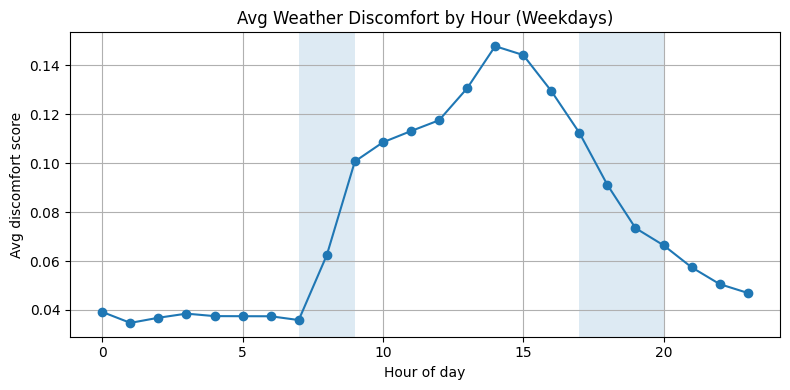

In [93]:
weekday = w[~w["is_weekend"]]

hourly = (
    weekday
    .groupby("hour")["discomfort_score"]
    .mean()
)

plt.figure(figsize=(8,4))
plt.plot(hourly.index, hourly.values, marker="o")
plt.axvspan(7, 9, alpha=0.15)       # AM peak
plt.axvspan(17, 20, alpha=0.15)     # PM peak
plt.xlabel("Hour of day")
plt.ylabel("Avg discomfort score")
plt.title("Avg Weather Discomfort by Hour (Weekdays)")
plt.grid(True)
plt.tight_layout()
plt.show()


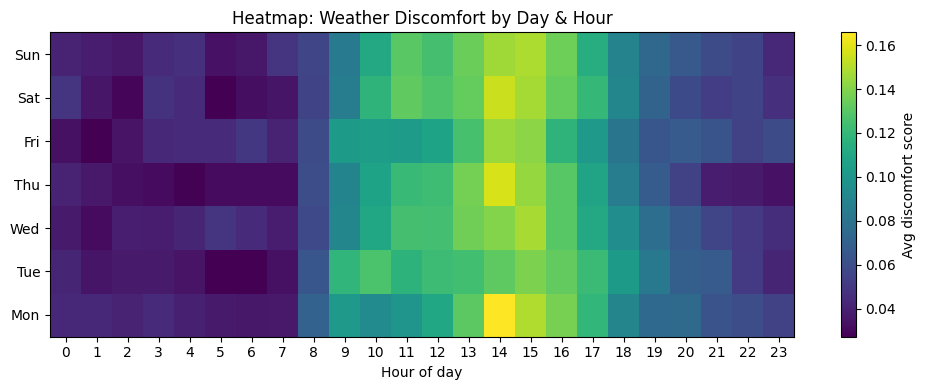

In [97]:
pivot = (
    w
    .groupby(["dow","hour"])["discomfort_score"]
    .mean()
    .unstack("hour")
    .reindex(index=[0,1,2,3,4,5,6])  # Mon..Sun
)

plt.figure(figsize=(10,4))
plt.imshow(pivot, aspect="auto", origin="lower")
plt.colorbar(label="Avg discomfort score")
plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.xticks(range(24), range(24))
plt.xlabel("Hour of day")
plt.title("Heatmap: Weather Discomfort by Day & Hour")
plt.tight_layout()
plt.show()


In [99]:
w_peak["scenario"] = np.select(
    [
        w_peak["heavy_rain"],
        w_peak["hot_humid"],
        w_peak["heavy_rain"] & w_peak["hot_humid"]
    ],
    [
        "Rain_only",
        "HotHumid_only",
        "Both_Rain_and_HotHumid"
    ],
    default="None"
)

print(w_peak["scenario"].value_counts(normalize=True))


scenario
None             0.989270
HotHumid_only    0.010314
Rain_only        0.000416
Name: proportion, dtype: float64


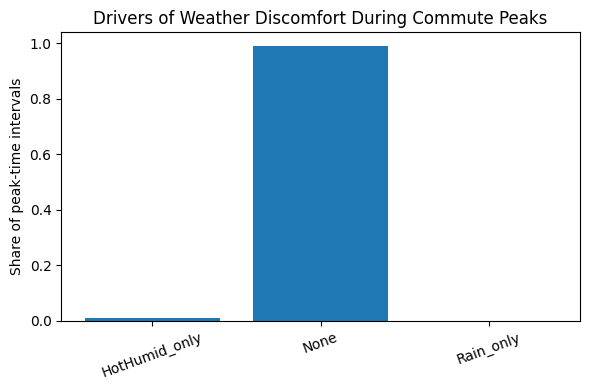

In [100]:
scenario_share = w_peak["scenario"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(6,4))
plt.bar(scenario_share.index, scenario_share.values)
plt.ylabel("Share of peak-time intervals")
plt.title("Drivers of Weather Discomfort During Commute Peaks")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

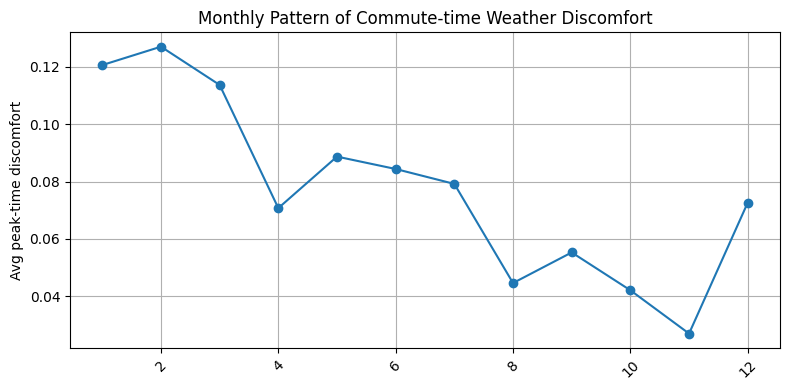

In [124]:
monthly = (
    w_peak
    .groupby("month_num")["discomfort_score"]
    .mean()
)

plt.figure(figsize=(8,4))
plt.plot(monthly.index, monthly.values, marker="o")
plt.ylabel("Avg peak-time discomfort")
plt.title("Monthly Pattern of Commute-time Weather Discomfort")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [122]:
w["month_num"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)